# Bayesian Ridge Regression – Complete Machine Learning Pipeline

This notebook demonstrates how to train, tune, and evaluate a **Bayesian Ridge Regression model** using scikit-learn.

Steps included:
- Data loading
- Data preprocessing
- Feature engineering
- Train/test split
- Model training
- Hyperparameter tuning
- Model evaluation
- Visualization

### What is Bayesian Ridge Regression?

**Bayesian Ridge Regression** is a probabilistic version of Ridge Regression.

Instead of finding **a single best weight**, it **estimates a probability distribution over weights** using **Bayesian inference**.

It assumes:

$$ y = Xw + \epsilon $$

Where:

* (w) follows a **Gaussian prior**
* Noise follows a **Gaussian distribution**

This allows the model to **automatically estimate regularization parameters**.


# When to Use Bayesian Ridge

Use Bayesian Ridge when:

* Dataset is **small or medium sized**
* You want **uncertainty estimates**
* Multicollinearity exists
* Overfitting risk exists
* Linear relationships dominate

Common applications:

* House price prediction
* Financial forecasting
* Scientific modeling
* Medical prediction


# Advantages

```
1️. Automatic regularization
2️. Prevents overfitting
3️. Provides uncertainty estimation
4️. Works well with small datasets
5️. Handles multicollinearity
```

# Disadvantages

```
1️. Slower than simple Linear Regression
2️. Assumes Gaussian priors
3️. Less interpretable than OLS
4️. Not suitable for very large datasets
```

# Important Hyperparameters

### alpha_1

- Prior for noise precision.
- Higher value → stronger regularization.


### alpha_2

- Precision of noise prior.
- Controls noise variance estimation.


### lambda_1

- Prior for weight precision.
- Controls weight distribution.



### lambda_2

- Second hyperparameter for weight precision.
- Helps stabilize Bayesian estimation.


# Practical Tuning Tips

### 1️. Always scale features

Bayesian models perform best with **standardized features**.

```
StandardScaler
```

### 2️. Use GridSearchCV

Tune:

```
alpha_1
alpha_2
lambda_1
lambda_2
```


### 3️. Use learning curves

Check:

* Overfitting
* Underfitting

### 4️. Compare with other regressors

Compare with:

* Linear Regression
* Ridge
* Lasso
* ElasticNet


### 5️. Works best with linear relationships

If relationship is nonlinear → try:

* Random Forest
* XGBoost
* Neural Networks


If you want, I can also show you a **much more advanced "Professional ML Engineer level" notebook** including:

* **Pipelines**
* **Feature selection**
* **Cross validation**
* **Model comparison**
* **SHAP explainability**
* **MLflow experiment tracking**

This is the type of notebook **used in real ML industry projects**.


**Importing Libraries**

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn datasets
from sklearn.datasets import fetch_california_housing

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Train test split
from sklearn.model_selection import train_test_split

# Model
from sklearn.linear_model import BayesianRidge

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Learning curve
from sklearn.model_selection import learning_curve

**Load dataset**

In [2]:
# Load California Housing dataset
data = fetch_california_housing()

In [3]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [4]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature shape: (20640, 8)
Target shape: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


**Data Cleaning & Exploration**

In [5]:
# Dataset information
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [6]:
# Check missing values
print("Missing Values:\n", X.isnull().sum())

Missing Values:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [7]:
# Basic statistics
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


**Feature Engineering**

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**Train-Test Split**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (16512, 8)
Test set size: (4128, 8)


**Model Creation**

In [11]:
model = BayesianRidge()

**Hyperparameter Tuning with GridSearchCV**

In [12]:
param_grid = {
    "alpha_1": [1e-6, 1e-5, 1e-4],
    "alpha_2": [1e-6, 1e-5, 1e-4],
    "lambda_1": [1e-6, 1e-5, 1e-4],
    "lambda_2": [1e-6, 1e-5, 1e-4]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'alpha_1': 0.0001, 'alpha_2': 1e-06, 'lambda_1': 1e-06, 'lambda_2': 0.0001}


**Train Final Model**

In [13]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

BayesianRidge(alpha_1=0.0001, lambda_2=0.0001)

**Model Evaluation**

In [14]:
# Predictions
y_pred = best_model.predict(X_test)

In [15]:
# Regression Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [16]:
print("Evaluation Metrics:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

Evaluation Metrics:
MSE : 0.5558255170943325
RMSE: 0.7455370662108843
MAE : 0.5331891875618389
R2  : 0.5758381342590648


**Prediction vs Actual Visualization**

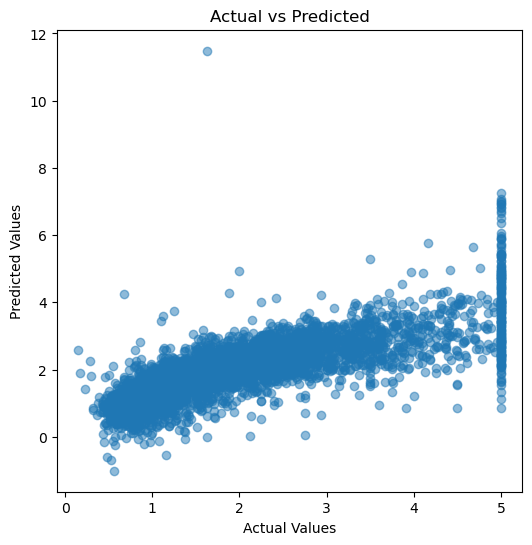

In [17]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

**Residual Plot**

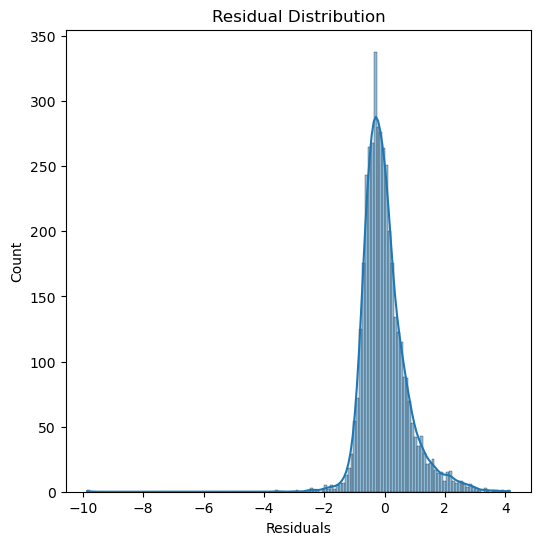

In [18]:
residuals = y_test - y_pred

plt.figure(figsize=(6,6))
sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Residuals")

plt.show()

**Learning Curve**

In [19]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_scaled,
    y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1,1.0,10)
)

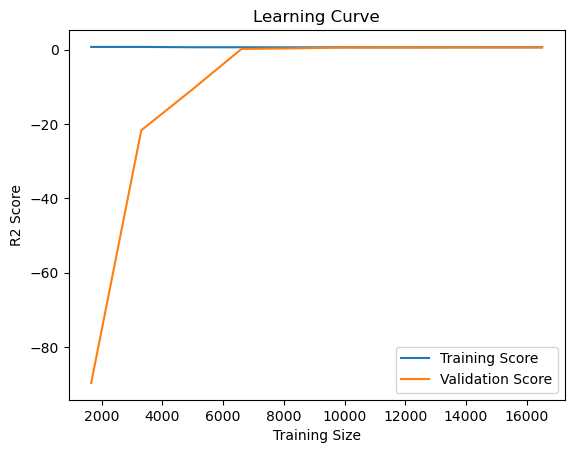

In [20]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve")
plt.legend()

plt.show()